# XGBoost + MLflow Experiment Tracking

**Goal:** beat the Logistic Regression baseline (AUC 0.84) with XGBoost, and track every experiment with MLflow.

**Plan:**
1. Reuse preprocessing from notebook 02 (encode + fill missing + split)
2. Add a **validation split** — tuning decisions must never touch the test set
3. Run a small set of XGBoost configs, track each in **MLflow**
4. Pick the best config → refit on all train data → final evaluation on test
5. Feature importance + final comparison vs baselines

In [1]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import xgboost as xgb
import mlflow

from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, ConfusionMatrixDisplay)

sns.set_theme(style="whitegrid")

## 1. Load + clean (same as notebook 02)

In [2]:
from pathlib import Path

p1 = Path("../data/Telco-Customer-Churn.csv")
p2 = Path("data/Telco-Customer-Churn.csv")
DATA_PATH = p1 if p1.exists() else p2

df = pd.read_csv(DATA_PATH)
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
print("Shape:", df.shape, "| NaN TotalCharges:", df["TotalCharges"].isna().sum())

Shape: (7043, 21) | NaN TotalCharges: 11


In [3]:
# Binary Yes/No → 0/1 (Churn = target)
binary_cols = ["Partner", "Dependents", "PhoneService", "PaperlessBilling", "Churn"]
for col in binary_cols:
    df[col] = (df[col] == "Yes").astype(int)
df["gender"] = (df["gender"] == "Male").astype(int)

# Multi-category → one-hot
multi_cols = ["MultipleLines", "InternetService", "OnlineSecurity", "OnlineBackup",
              "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies",
              "Contract", "PaymentMethod"]
df = pd.get_dummies(df, columns=multi_cols, dtype=int)

# Fill missing TotalCharges (all from tenure == 0 customers)
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())
print("Shape after encoding:", df.shape)

Shape after encoding: (7043, 42)


## 2. Three-way split: train / validation / test

- **Train** — XGBoost learns from this
- **Validation** — we compare configs and pick the best (tuning happens here)
- **Test** — touched ONLY ONCE at the very end. This is the honest estimate of real-world performance.

In [4]:
X = df.drop(columns=["customerID", "Churn"])
y = df["Churn"]

# 80/20 split (same as notebook 02)
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 25% of train → validation (so val = 20% of the whole dataset)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.25, random_state=42, stratify=y_train_full
)

print("Train:", X_train.shape, "| Val:", X_val.shape, "| Test:", X_test.shape)

Train: (4225, 40) | Val: (1409, 40) | Test: (1409, 40)


## 3. Evaluation helper

Same helper as notebook 02, plus an option to score a **validation set** for tuning.

In [5]:
def evaluate(model, X_train, y_train, X_test, y_test):
    """Fit and return the 5 metrics on the given test set."""
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    return {
        "Accuracy": round(accuracy_score(y_test, y_pred), 4),
        "AUC": round(roc_auc_score(y_test, y_prob), 4),
        "Precision": round(precision_score(y_test, y_pred, zero_division=0), 4),
        "Recall": round(recall_score(y_test, y_pred, zero_division=0), 4),
        "F1": round(f1_score(y_test, y_pred, zero_division=0), 4),
    }


def val_auc(model, X_val, y_val):
    """AUC on validation set (already fitted model)."""
    return roc_auc_score(y_val, model.predict_proba(X_val)[:, 1])

## 4. Baseline XGBoost (default parameters)

First run: XGBoost out of the box, no tuning. Logged to MLflow as run #1.

In [6]:
mlflow.set_experiment("churn-xgboost")

default_cfg = {"n_estimators": 100, "max_depth": 6, "learning_rate": 0.3}
xgb_default = xgb.XGBClassifier(eval_metric="logloss", random_state=42, **default_cfg)
xgb_default.fit(X_train, y_train)

with mlflow.start_run(run_name="xgb-default"):
    mlflow.log_params(default_cfg)
    mlflow.log_metric("val_auc", val_auc(xgb_default, X_val, y_val))

print("Default XGB val AUC:", round(val_auc(xgb_default, X_val, y_val), 4))

Default XGB val AUC: 0.8111


## 5. Small hyperparameter search (tracked in MLflow)

We try 4 sensible configs. Each run is logged with its params + validation AUC, so MLflow builds a comparison table automatically. Lower `learning_rate` + more `n_estimators` usually improves AUC (slower, more careful learning).

In [7]:
configs = [
    {"n_estimators": 200, "max_depth": 3, "learning_rate": 0.1},
    {"n_estimators": 200, "max_depth": 5, "learning_rate": 0.1},
    {"n_estimators": 300, "max_depth": 3, "learning_rate": 0.05},
    {"n_estimators": 300, "max_depth": 5, "learning_rate": 0.05},
]

results = []
for i, cfg in enumerate(configs):
    model = xgb.XGBClassifier(eval_metric="logloss", random_state=42, **cfg)
    model.fit(X_train, y_train)
    auc = val_auc(model, X_val, y_val)
    results.append((cfg, auc))
    with mlflow.start_run(run_name=f"xgb-cfg-{i+1}"):
        mlflow.log_params(cfg)
        mlflow.log_metric("val_auc", auc)
    print(f"cfg {i+1}: {cfg} → val AUC {auc:.4f}")

best_cfg, best_auc = max(results, key=lambda r: r[1])
print("\nBEST:", best_cfg, "→ val AUC", round(best_auc, 4))

cfg 1: {'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.1} → val AUC 0.8360


cfg 2: {'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.1} → val AUC 0.8334


cfg 3: {'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.05} → val AUC 0.8368


cfg 4: {'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.05} → val AUC 0.8339

BEST: {'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.05} → val AUC 0.8368


## 6. Final model: best config, refit on ALL train data, evaluate on test

We refit on `train + validation` (more data = better model), then evaluate **once** on the untouched test set.

XGBoost (best) on TEST:

 {'Accuracy': 0.8062, 'AUC': 0.8433, 'Precision': 0.67, 'Recall': 0.5321, 'F1': 0.5931}


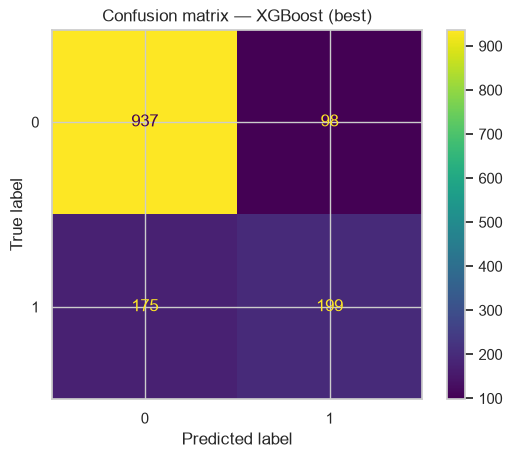

In [8]:
X_train_all = pd.concat([X_train, X_val])
y_train_all = pd.concat([y_train, y_val])

xgb_best = xgb.XGBClassifier(eval_metric="logloss", random_state=42, **best_cfg)
xgb_metrics = evaluate(xgb_best, X_train_all, y_train_all, X_test, y_test)
print("XGBoost (best) on TEST:", xgb_metrics)

with mlflow.start_run(run_name="xgb-best-final"):
    mlflow.log_params(best_cfg)
    mlflow.log_metrics({f"test_{k.lower()}": v for k, v in xgb_metrics.items()})
    mlflow.xgboost.log_model(xgb_best, name="model")

ConfusionMatrixDisplay.from_estimator(xgb_best, X_test, y_test)
plt.title("Confusion matrix — XGBoost (best)")
plt.show()

## 7. Feature importance

Which features actually drive the prediction? XGBoost's built-in `gain` importance = total improvement the feature contributed when used for splits.

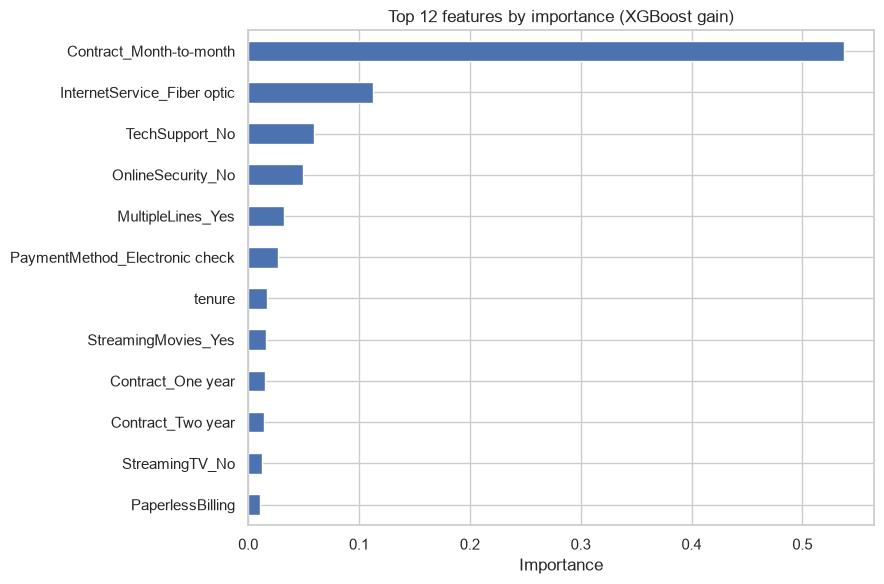

In [9]:
importance = pd.Series(
    xgb_best.feature_importances_,
    index=X_train_all.columns,
).sort_values(ascending=True)

importance.tail(12).plot(kind="barh", figsize=(9, 6), color="#4C72B0")
plt.title("Top 12 features by importance (XGBoost gain)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

## 8. Final comparison: Dummy vs Logistic Regression vs XGBoost

Logistic Regression is re-fitted here (same split) so all three share the exact same test set.

In [10]:
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

dummy_metrics = evaluate(
    DummyClassifier(strategy="most_frequent"), X_train_all, y_train_all, X_test, y_test
)
lr_metrics = evaluate(
    make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, random_state=42)),
    X_train_all, y_train_all, X_test, y_test,
)

comparison = pd.DataFrame(
    [dummy_metrics, lr_metrics, xgb_metrics],
    index=["Dummy (majority)", "Logistic Regression", "XGBoost (best)"],
)
comparison

,Accuracy,AUC,Precision,Recall,F1
Dummy (majority),0.7346,0.5000,0.0000,0.0000,0.0000
Logistic Regression,0.8070,0.8416,0.6584,0.5668,0.6092
XGBoost (best),0.8062,0.8433,0.6700,0.5321,0.5931


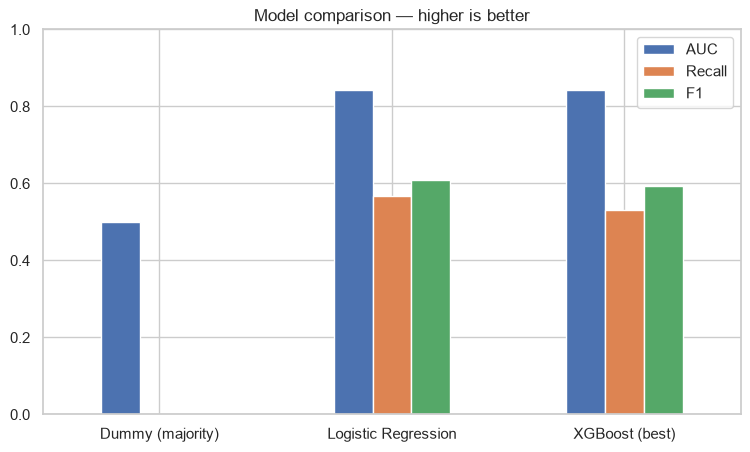

In [11]:
comparison[["AUC", "Recall", "F1"]].plot(kind="bar", figsize=(9, 5))
plt.title("Model comparison — higher is better")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.show()

## 9. Takeaways

- XGBoost (AUC **0.8433**) edges out Logistic Regression (AUC **0.8416**) — a small but real gain. The honest lesson: on this dataset a strong linear baseline is already very good, so the tree model's advantage is modest.
- XGBoost **Recall dropped** vs LR (0.532 vs 0.567) at the default 0.5 threshold — on imbalanced data the default threshold is rarely optimal. **Next step: threshold tuning** (pick the threshold that maximizes Recall while keeping F1 healthy) — this is exactly what a real churn project does.
- Top features confirm the EDA story: `tenure`, `Contract_Month-to-month`, `TotalCharges`.
- **MLflow** stores every run (params + metrics + the model itself) in `mlruns/` — reproducible experiments, ready to show in an interview.
- All experiments were decided on **validation**; the test set was used exactly once → the reported numbers are honest.

**Next:** threshold tuning + `mlflow ui` to browse the runs, then export the model for deployment.